In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib

In [2]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/station_1.nc
<xarray.Dataset>
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 ...
  * valid_time           (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-3...
    latitude             float64 ...
    longitude            float64 ...
    station_latitude     float64 ...
    station_longitude    float64 ...
    year                 (valid_time) int64 ...
Data variables: (12/15)
    u10                  (valid_time) float32 ...
    v10                  (valid_time) float32 ...
    d2m                  (valid_time) float32 ...
    t2m                  (valid_time) float32 ...
    msl                  (valid_time) float32 ...
    sst                  (valid_time) float32 ...
    ...                   ...
    mwp                  (valid_time) float32 ...
    swh                  (valid_time) float32 ...
    sea_level            (valid_time) float32 ...
    tide                 (vali

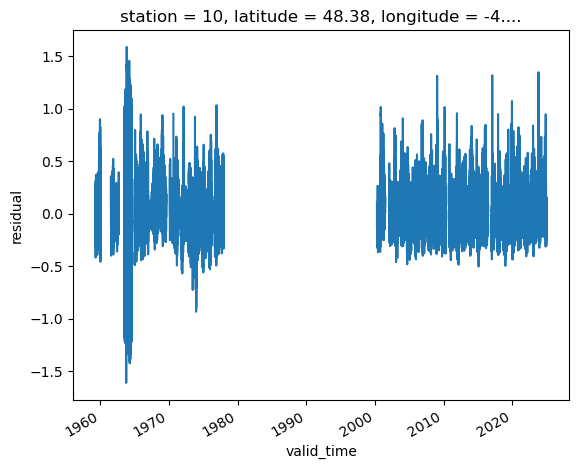

In [11]:
da = datasets[1].residual
da.plot()

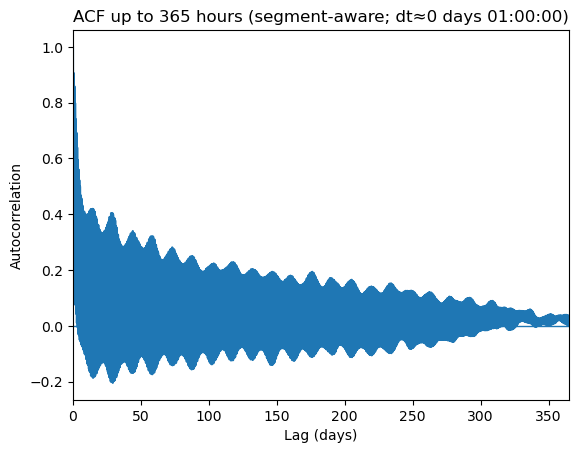

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

def plot_acf_upto_365d(da, time_name="valid_time", max_days=365, gap_factor=5,
                      fill_small_gaps=True, small_gap_max_steps=3, fft=True):
    """
    da: 1D xr.DataArray with a datetime coordinate (time_name)
    gap_factor: split segments when dt > gap_factor * median_dt
    fill_small_gaps: interpolate small NaN runs within segments only
    small_gap_max_steps: max consecutive NaN steps to fill within a segment
    """

    # Convert to pandas Series for convenience
    s = da.to_series()
    s = s.sort_index()

    # Estimate nominal sampling interval
    dt = s.index.to_series().diff().median()
    if pd.isna(dt) or dt <= pd.Timedelta(0):
        raise ValueError("Could not infer a valid sampling interval from the time coordinate.")
    max_lag = int(pd.Timedelta(days=max_days) / dt)

    # Identify big gaps and split into segments
    gap = s.index.to_series().diff() > (gap_factor * dt)
    seg_id = gap.cumsum()

    acfs = []
    weights = []

    for _, seg in s.groupby(seg_id):
        # Drop leading/trailing NaNs
        seg = seg.dropna(how="all")
        if len(seg) < (max_lag + 2):
            continue

        # Handle NaNs inside the segment
        if seg.isna().any():
            if fill_small_gaps:
                # Only fill small NaN runs; leave longer missing stretches as NaN
                is_nan = seg.isna().to_numpy()
                if is_nan.any():
                    # find run lengths of NaNs
                    nan_runs = []
                    start = None
                    for i, v in enumerate(is_nan):
                        if v and start is None:
                            start = i
                        if not v and start is not None:
                            nan_runs.append((start, i-1))
                            start = None
                    if start is not None:
                        nan_runs.append((start, len(is_nan)-1))

                    seg_vals = seg.to_numpy().copy()
                    for a, b in nan_runs:
                        run_len = b - a + 1
                        if run_len <= small_gap_max_steps:
                            # interpolate only this short run
                            x = np.arange(len(seg_vals))
                            good = ~np.isnan(seg_vals)
                            seg_vals[a:b+1] = np.interp(x[a:b+1], x[good], seg_vals[good])
                    seg = pd.Series(seg_vals, index=seg.index)
            # After optional small-gap fill, drop remaining NaNs (prevents artifacts)
            seg = seg.dropna()

        if len(seg) < (max_lag + 2):
            continue

        y = seg.to_numpy()
        y = y - np.mean(y)

        # Efficient ACF computation
        a = acf(y, nlags=max_lag, fft=fft)
        acfs.append(a)
        weights.append(len(y))  # weight by segment length

    if not acfs:
        raise ValueError("No segment long enough to compute ACF up to 365 days after NaN/gap handling.")

    # Weighted average across segments (optional but usually sensible)
    A = np.vstack(acfs)
    w = np.asarray(weights, float)
    acf_mean = np.average(A, axis=0, weights=w)

    lags = np.arange(len(acf_mean))
    lags_days = (lags * dt) / pd.Timedelta(days=1)

    plt.figure()
    plt.plot(lags_days, acf_mean)
    plt.xlabel("Lag (days)")
    plt.ylabel("Autocorrelation")
    plt.title(f"ACF up to {max_days} hours (segment-aware; dt≈{dt})")
    plt.xlim(0, max_days)
    plt.axhline(0, linewidth=1)
    plt.show()

    return lags_days, acf_mean, dt, seg
lags_days, acf_mean, dt, seg = plot_acf_upto_365d(da, time_name="valid_time", max_days=365, gap_factor=5,
                      fill_small_gaps=True, small_gap_max_steps=3, fft=True)

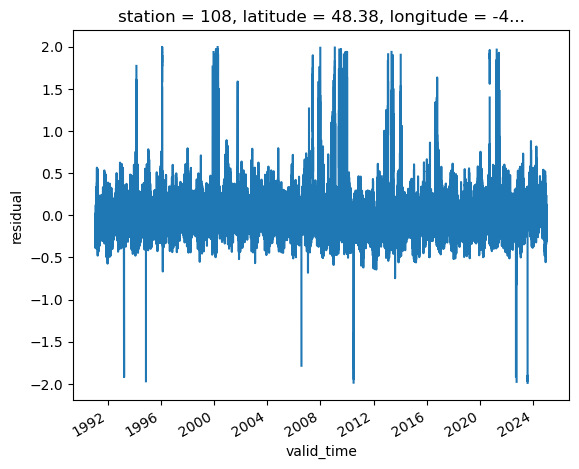

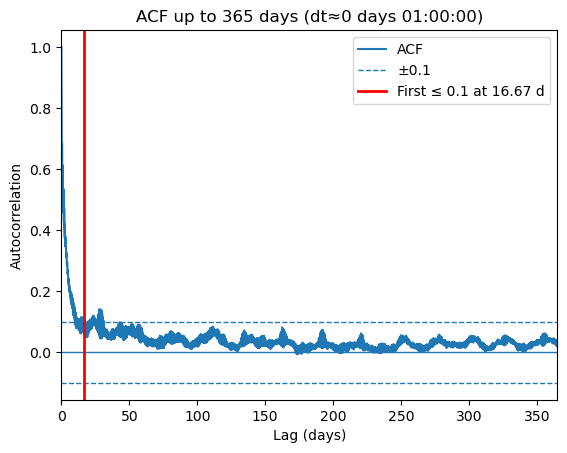

First lag where |ACF| ≤ 0.1 (sustained for 24h): 16.67 days


In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf

def plot_acf_upto_365d_with_threshold(
    da, time_name="valid_time", max_days=365, gap_factor=5,
    fill_small_gaps=True, small_gap_max_steps=3, fft=True,
    threshold=0.15, sustain_hours=24, plot=True
):
    # Convert to pandas Series (datetime index)
    s = da.to_series().sort_index()

    # Nominal sampling interval (e.g., 1 hour)
    dt = s.index.to_series().diff().median()
    if pd.isna(dt) or dt <= pd.Timedelta(0):
        raise ValueError("Could not infer a valid sampling interval from the time coordinate.")

    max_lag = int(pd.Timedelta(days=max_days) / dt)

    # Split on big gaps (do NOT interpolate across massive gaps)
    gap = s.index.to_series().diff() > (gap_factor * dt)
    seg_id = gap.cumsum()

    acfs, weights = [], []

    for _, seg in s.groupby(seg_id):
        seg = seg.dropna(how="all")
        if len(seg) < (max_lag + 2):
            continue

        # Fill only small NaN runs, then drop remaining NaNs
        if seg.isna().any():
            if fill_small_gaps:
                is_nan = seg.isna().to_numpy()
                nan_runs, start = [], None
                for i, v in enumerate(is_nan):
                    if v and start is None:
                        start = i
                    if not v and start is not None:
                        nan_runs.append((start, i - 1))
                        start = None
                if start is not None:
                    nan_runs.append((start, len(is_nan) - 1))

                seg_vals = seg.to_numpy().copy()
                x = np.arange(len(seg_vals))
                good = ~np.isnan(seg_vals)
                for a, b in nan_runs:
                    if (b - a + 1) <= small_gap_max_steps and good.any():
                        seg_vals[a:b+1] = np.interp(x[a:b+1], x[good], seg_vals[good])
                seg = pd.Series(seg_vals, index=seg.index)

            seg = seg.dropna()

        if len(seg) < (max_lag + 2):
            continue

        y = seg.to_numpy()
        y = y - np.mean(y)

        a = acf(y, nlags=max_lag, fft=fft)
        acfs.append(a)
        weights.append(len(y))

    if not acfs:
        raise ValueError("No segment long enough to compute ACF up to 365 days after NaN/gap handling.")

    # Weighted average ACF across segments
    A = np.vstack(acfs)
    w = np.asarray(weights, float)
    acf_mean = np.average(A, axis=0, weights=w)

    lags = np.arange(len(acf_mean))
    lags_days = (lags * dt) / pd.Timedelta(days=1)

    # Find first lag where |ACF| <= threshold for sustain_hours consecutively
    sustain = max(1, int(pd.Timedelta(hours=sustain_hours) / dt))
    tau_days = np.nan
    for i in range(len(acf_mean) - sustain):
        if np.all(np.abs(acf_mean[i:i+sustain]) <= threshold):
            tau_days = float(lags_days[i])
            break

    # Plot
    if plot == True:
        plt.figure()
        plt.plot(lags_days, acf_mean, label="ACF")
        plt.axhline(0, linewidth=1)
        plt.axhline(threshold, linestyle="--", linewidth=1, label=f"±{threshold}")
        plt.axhline(-threshold, linestyle="--", linewidth=1)

        if np.isfinite(tau_days):
            plt.axvline(tau_days, color="red", linewidth=2, label=f"First ≤ {threshold} at {tau_days:.2f} d")

        plt.xlabel("Lag (days)")
        plt.ylabel("Autocorrelation")
        plt.title(f"ACF up to {max_days} days (dt≈{dt})")
        plt.xlim(0, max_days)
        plt.legend()
        plt.show()

        if np.isfinite(tau_days):
            print(f"First lag where |ACF| ≤ {threshold} (sustained for {sustain_hours}h): {tau_days:.2f} days")
        else:
            print(f"ACF does not drop below |{threshold}| (sustained for {sustain_hours}h) within {max_days} days.")

    return lags_days, acf_mean, dt, tau_days

nr = 30
datasets[i].residual.plot()
# Usage
lags_days, acf_mean, dt, tau_days = plot_acf_upto_365d_with_threshold(
    datasets[i].residual,
    time_name="valid_time",
    max_days=365,
    gap_factor=5,
    fill_small_gaps=True,
    small_gap_max_steps=3,
    fft=True,
    threshold=0.1,
    sustain_hours=24
)


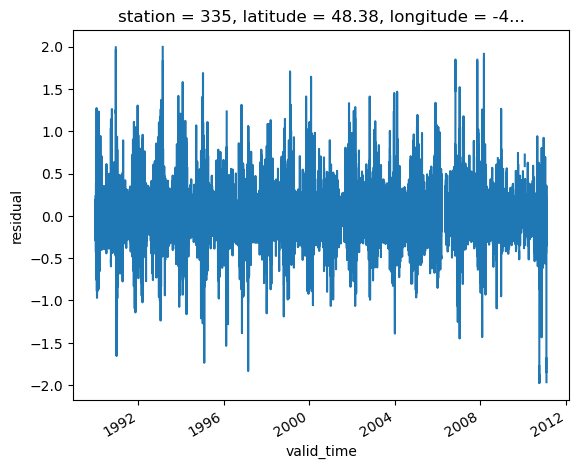

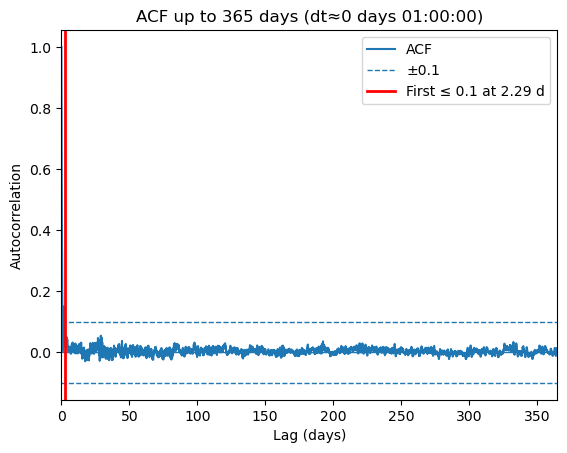

First lag where |ACF| ≤ 0.1 (sustained for 24h): 2.29 days


In [77]:
i= 121
datasets[i].residual.plot()
# Usage
lags_days, acf_mean, dt, tau_days = plot_acf_upto_365d_with_threshold(
    datasets[i].residual,
    time_name="valid_time",
    max_days=365,
    gap_factor=5,
    fill_small_gaps=True,
    small_gap_max_steps=3,
    fft=True,
    threshold=0.1,
    sustain_hours=24
)

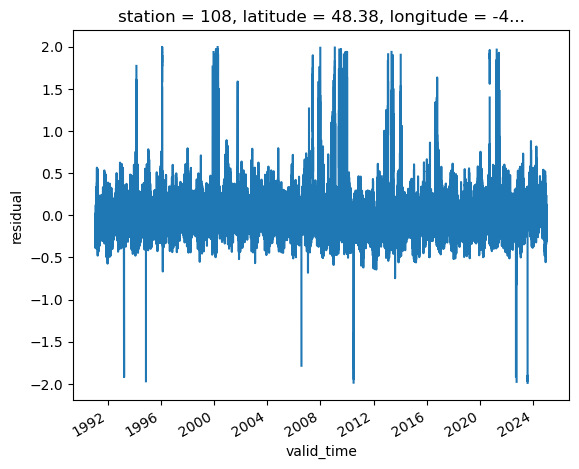

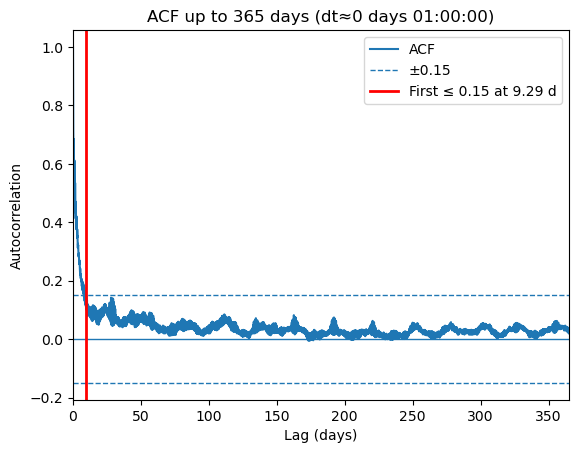

First lag where |ACF| ≤ 0.15 (sustained for 24h): 9.29 days


In [79]:
i= 5
datasets[i].residual.plot()
# Usage
lags_days, acf_mean, dt, tau_days = plot_acf_upto_365d_with_threshold(
    datasets[i].residual,
    time_name="valid_time",
    max_days=365,
    gap_factor=5,
    fill_small_gaps=True,
    small_gap_max_steps=3,
    fft=True,
    threshold=0.15,
    sustain_hours=24
)

In [68]:
datasets[100]

<xarray.Dataset>
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 264
  * valid_time           (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-3...
    latitude             float64 48.38
    longitude            float64 -4.495
    station_latitude     float64 51.38
    station_longitude    float64 4.165
    year                 (valid_time) int64 1940 1940 1940 ... 2025 2025 2025
Data variables: (12/15)
    u10                  (valid_time) float32 1.469 1.018 ... 3.809 4.392
    v10                  (valid_time) float32 0.7345 0.6668 ... 2.685 2.376
    d2m                  (valid_time) float32 272.5 273.0 271.4 ... 286.3 287.2
    t2m                  (valid_time) float32 273.5 274.0 272.3 ... 291.5 291.3
    msl                  (valid_time) float32 1.019e+05 1.019e+05 ... 1.017e+05
    sst                  (valid_time) float32 nan nan nan nan ... nan nan nan
    ...                   ...
    mwp                  (valid_time) float32 6.153 6.164 6.149 ... 5.291 5.114
    swh                  (valid_time) float32 0.7612 0.7368 ... 0.8574 0.8916
    sea_level            (valid_time) float32 nan nan nan nan ... nan nan nan
    tide                 (valid_time) float64 -2.406 -2.195 ... 0.3481 -0.7444
    residual             (valid_time) float32 nan nan nan nan ... nan nan nan
    residual_is_deviant  (valid_time) int8 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_edition:            1
    GRIB_subCentre:          0
    history:                 2024-09-02T04:48 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _first_present(d, keys):
    for k in keys:
        if k in d:
            return k
    return None

def extract_lat_lon_station(ds, fallback_station=None):
    """
    Attempts to extract (station_id, lat, lon) from ds.
    Works if lat/lon are in coords, data_vars, or attrs.
    """
    # Station id: prefer attrs if present, else fallback index
    station_id = (
        ds.attrs.get("station")
        or ds.attrs.get("station_id")
        or ds.attrs.get("id")
        or ds.attrs.get("name")
        or fallback_station
    )

    # Candidate names
    lat_keys = ["station_latitude", "lat", "Latitude", "LAT"]
    lon_keys = ["station_longitude", "lon", "Longitude", "LON"]

    # 1) coords
    lat_k = _first_present(ds.coords, lat_keys)
    lon_k = _first_present(ds.coords, lon_keys)

    lat = ds.coords[lat_k].values if lat_k else None
    lon = ds.coords[lon_k].values if lon_k else None

    # 2) data_vars (sometimes stored as variables)
    if lat is None:
        lat_k = _first_present(ds.data_vars, lat_keys)
        if lat_k:
            lat = ds[lat_k].values
    if lon is None:
        lon_k = _first_present(ds.data_vars, lon_keys)
        if lon_k:
            lon = ds[lon_k].values

    # 3) attrs
    if lat is None:
        for k in lat_keys:
            if k in ds.attrs:
                lat = ds.attrs[k]
                break
    if lon is None:
        for k in lon_keys:
            if k in ds.attrs:
                lon = ds.attrs[k]
                break

    # Convert to scalars if arrays
    def to_scalar(x):
        if x is None:
            return np.nan
        x = np.asarray(x)
        return float(x.ravel()[0]) if x.size else np.nan

    return station_id, to_scalar(lat), to_scalar(lon)
results = []

for idx, ds in enumerate(datasets):
    try:
        # pull location metadata
        station_id, lat, lon = extract_lat_lon_station(ds, fallback_station=idx)

        # compute tau (first sustained lag <= 0.1) on residual
        _, _, _, tau_days = plot_acf_upto_365d_with_threshold(
            ds["residual"],
            time_name="valid_time",
            max_days=365,
            gap_factor=5,
            fill_small_gaps=True,
            small_gap_max_steps=3,
            fft=True,
            threshold=0.15,
            sustain_hours=24,
            plot=False
        )

        results.append(
            {
                "station": station_id,
                "idx": idx,
                "lat": lat,
                "lon": lon,
                "decorrelation_days": tau_days,
            }
        )

    except Exception as e:
        # keep a record of failures rather than crashing the loop
        station_id, lat, lon = extract_lat_lon_station(ds, fallback_station=idx)
        results.append(
            {
                "station": station_id,
                "idx": idx,
                "lat": lat,
                "lon": lon,
                "decorrelation_days": np.nan,
                "error": str(e),
            }
        )

df = pd.DataFrame(results)
df

,station,idx,lat,lon,decorrelation_days,error
0,0,0,48.383000,-4.495000,9.833333,NaN
1,1,1,45.568480,-1.061555,165.208333,NaN
2,2,2,50.102000,-5.542000,9.791667,NaN
3,3,3,50.103000,-5.542750,75.125000,NaN
4,4,4,50.099998,-5.533330,16.666667,NaN
...,...,...,...,...,...,...
290,290,290,49.481602,0.105600,6.333333,NaN
291,291,291,49.651299,-1.635500,7.750000,NaN
292,292,292,49.431831,0.110670,NaN,No segment long enough to compute ACF up to 36...
293,293,293,49.183300,-2.116700,8.750000,NaN


In [104]:
basin_boxes = {
    # lon_min, lon_max, lat_min, lat_max

    # West Ireland (keep separate)
    "West Ireland":           (-11.5,  -6.2, 51.3, 56.6),

    # Expanded: Irish Sea + West Scotland + extend east into north/east Scotland
    # Covers Irish Sea, Inner/Outer Hebrides, Minch, and across to Moray Firth-ish
    "Irish Sea & West Scotland": ( -6.8,   -1, 53.0, 59.2),

    # Severn / Bristol Channel (keep tight)
    "Severn Estuary":         ( -5.4,  -2.6, 50.0, 52.2),

    # English Channel (keep below ~51N to avoid collisions)
    "English Channel":        ( -6.6,   1.8, 48.8, 50.9),

    # East Coast UK (southern/central east coast; exclude the new Scotland extension by lat cap)
    "East Coast UK":          ( -2.2,   1.3, 51.2, 58),

    # Southern North Sea (east of UK into NL/BE; start east of ~1.3E)
    "Southern North Sea":     ( 0.3,   6.8, 51.0, 55.8),

    "German Bight":           (  6.2,   9.6, 53.1, 56.0),
    "East of Denmark":        (  8.5,  15.5, 54.2, 58.8),

    # Norway (trim to your map extent; adjust north if needed)
    "Norway":                 (  4.0,  12.0, 57.4, 62.2),

    "South of France":        ( -6.6,   1.8, 44.8, 48.9),
}



def draw_basin_boxes(ax, basin_boxes, alpha=0.12, lw=1.5):
    for name, (lon0, lon1, lat0, lat1) in basin_boxes.items():
        rect = mpatches.Rectangle(
            (lon0, lat0),
            lon1 - lon0,
            lat1 - lat0,
            transform=ccrs.PlateCarree(),
            fill=True,
            alpha=alpha,
            linewidth=lw,
            edgecolor="black",
            facecolor="none",  # keep transparent interior; change to e.g. "black" if you want shading
            zorder=3,
        )
        ax.add_patch(rect)

        # Label in the center of the box
        ax.text(
            (lon0 + lon1) / 2,
            (lat0 + lat1) / 2,
            name,
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=8,
            zorder=4,
        )

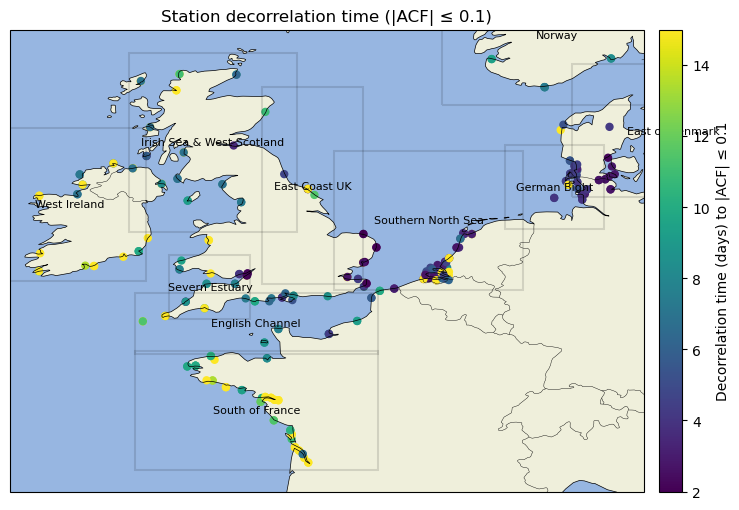

In [105]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Keep only rows with valid coordinates and tau
plot_df = df.dropna(subset=["lat", "lon", "decorrelation_days"]).copy()

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, linewidth=0.2)
ax.add_feature(cfeature.OCEAN, linewidth=0.2)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.3)

sc = ax.scatter(
    plot_df["lon"].values,
    plot_df["lat"].values,
    c=plot_df["decorrelation_days"].values,
    s=25,
    vmin=2,
    vmax=15,
    transform=ccrs.PlateCarree(),
)


cb = plt.colorbar(sc, ax=ax, orientation="vertical", pad=0.02)
cb.set_label("Decorrelation time (days) to |ACF| ≤ 0.1")

# Reasonable map extent around points
min_lon, max_lon = plot_df["lon"].min(), plot_df["lon"].max()
min_lat, max_lat = plot_df["lat"].min(), plot_df["lat"].max()
ax.set_extent([min_lon - 1, max_lon + 1, min_lat - 1, max_lat + 1], crs=ccrs.PlateCarree())
draw_basin_boxes(ax, basin_boxes)
ax.set_title("Station decorrelation time (|ACF| ≤ 0.1)")
plt.show()


In [107]:
import numpy as np
import pandas as pd

# Priority order (must match your basin_boxes keys)
basin_order = [
    "Severn Estuary",
    "English Channel",
    "West Ireland",
    "Irish Sea & West Scotland",
    "Southern North Sea",
    "East Coast UK",
    "German Bight",
    "East of Denmark",
    "Norway",
    "South of France",
]

def assign_basin_from_boxes(lat, lon, basin_boxes, basin_order):
    # normalize lon if needed
    if pd.isna(lat) or pd.isna(lon):
        return np.nan
    lon = float(lon)
    lat = float(lat)
    if lon > 180:
        lon -= 360

    for b in basin_order:
        lon0, lon1, lat0, lat1 = basin_boxes[b]
        if (lat0 <= lat <= lat1) and (lon0 <= lon <= lon1):
            return b
    return np.nan

# Apply classification using basin_boxes
df2 = df.copy()
df2["basin"] = [
    assign_basin_from_boxes(lat, lon, basin_boxes, basin_order)
    for lat, lon in zip(df2["lat"], df2["lon"])
]

# Keep only classified rows with valid decorrelation
df_basin = df2.dropna(subset=["basin", "decorrelation_days"]).copy()

# Inspect unclassified stations (optional)
unclassified = df2[df2["basin"].isna()][["station", "lat", "lon", "decorrelation_days"]]
print("Unclassified stations:", len(unclassified))

# Basin-based summary table
basin_stats = (
    df_basin.groupby("basin")["decorrelation_days"]
    .agg(mean="mean", median="median", n="count", std="std")
    .reindex(basin_order)
    .reset_index()
)

basin_stats



Unclassified stations: 7


,basin,mean,median,n,std
0,Severn Estuary,14.045833,7.583333,20,22.831820
1,English Channel,11.256173,8.250000,27,13.740730
2,West Ireland,17.319444,13.500000,21,12.670753
3,Irish Sea & West Scotland,21.126543,7.791667,27,32.102622
4,Southern North Sea,14.756194,3.687500,74,34.144260
5,East Coast UK,10.225000,11.458333,5,6.404724
6,German Bight,5.502874,4.541667,29,5.352307
7,East of Denmark,2.837963,2.791667,9,0.550979
8,Norway,8.458333,8.250000,7,0.901067
9,South of France,31.273050,13.416667,47,38.016989


/var/folders/2b/rpgq1g5d5qz2nhbpj5s4jnrc0000gq/T/ipykernel_48560/2358281928.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(plot_stats["basin"], rotation=30, ha="right")


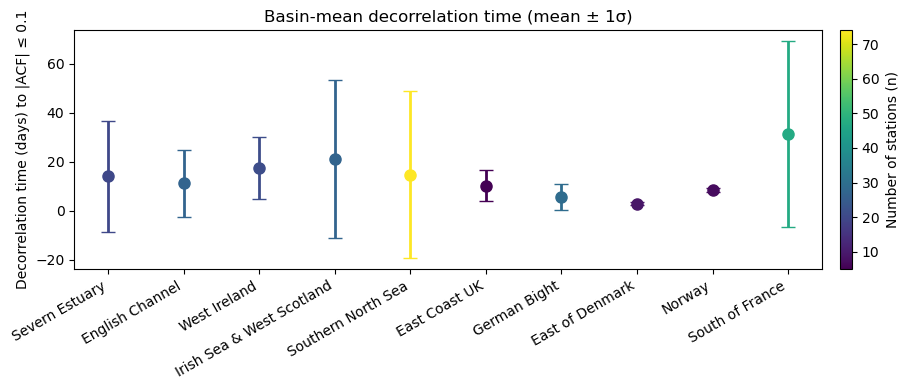

In [109]:
import matplotlib.pyplot as plt
import numpy as np

plot_stats = basin_stats.dropna(subset=["mean"]).copy()

# Use a perceptually uniform colormap
cmap = plt.cm.viridis
norm = plt.Normalize(plot_stats["n"].min(), plot_stats["n"].max())

fig, ax = plt.subplots(figsize=(10, 4))

for i, row in plot_stats.iterrows():
    ax.errorbar(
        row["basin"],
        row["mean"],
        yerr=row["std"],
        fmt="o",
        color=cmap(norm(row["n"])),
        capsize=5,
        markersize=8,
        linewidth=2,
    )

# Colorbar for sample size
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, pad=0.02)
cb.set_label("Number of stations (n)")

ax.set_ylabel("Decorrelation time (days) to |ACF| ≤ 0.1")
ax.set_title("Basin-mean decorrelation time (mean ± 1σ)")
ax.set_xticklabels(plot_stats["basin"], rotation=30, ha="right")

plt.tight_layout()
plt.show()


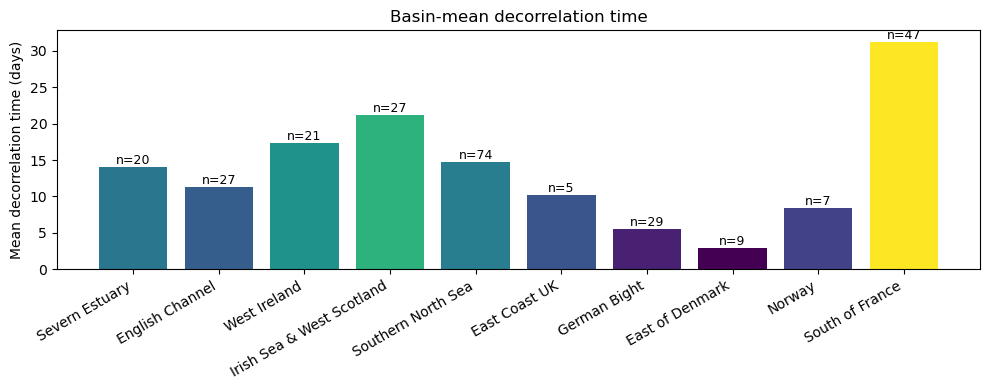

In [111]:
fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(
    plot_stats["basin"],
    plot_stats["mean"],
    color=plt.cm.viridis(
        (plot_stats["mean"] - plot_stats["mean"].min())
        / (plot_stats["mean"].max() - plot_stats["mean"].min())
    ),
)

ax.set_ylabel("Mean decorrelation time (days)")
ax.set_title("Basin-mean decorrelation time")

for bar, n in zip(bars, plot_stats["n"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"n={int(n)}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
